In [75]:
!pip install catboost

In [ ]:
from google.colab import drive
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

In [ ]:
np.random.seed(42)

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('coolwarm')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_base_dir = '/content/drive/MyDrive/project/autoscout'

In [ ]:
drive_data_dir = drive_base_dir+'/data'
drive_model_dir = drive_base_dir+'/model'
drive_plot_dir = drive_base_dir+'/plot'
drive_script_dir = drive_base_dir+'/script'

In [ ]:
!jupyter nbconvert --to script '{drive_base_dir}/modeling.ipynb'
!mv '{drive_base_dir}/modeling.py' '{drive_script_dir}'

[NbConvertApp] Converting notebook /content/drive/MyDrive/project/autoscout/modeling.ipynb to script
[NbConvertApp] Writing 24631 bytes to /content/drive/MyDrive/project/autoscout/modeling.py


In [ ]:
!cp /content/drive/MyDrive/project/autoscout/auto_scout_final.csv /content/drive/MyDrive/project/autoscout/data

### Dataset import

In [ ]:
df = pd.read_csv(drive_data_dir+'/auto_scout_final.csv')

In [ ]:
df.head()

,price,km,prev_owner,hp,inspection_new,warranty,nr_of_doors,nr_of_seats,displacement,cylinders,weight,co2_emission,gears,electricity_consumption,year,consumption_comb,make_model_Audi A2,make_model_Audi A3,make_model_Opel Astra,make_model_Opel Corsa,make_model_Opel Insignia,make_model_Renault Clio,make_model_Renault Duster,make_model_Renault Espace,body_type_Convertible,body_type_Coupe,body_type_Off-Road,body_type_Other,body_type_Sedans,body_type_Station wagon,body_type_Transporter,body_type_Van,vat_VAT deductible,vat_VAT undeductible,new_used_Employee's car,new_used_New,new_used_Pre-registered,new_used_Used,body_color_Black,body_color_Blue,body_color_Brown,body_color_Green,body_color_Grey,body_color_Others,body_color_Red,body_color_Silver,body_color_White,paint_type_Perl effect,paint_type_Uni/basic,gearing_type_Manual,gearing_type_Semi-automatic,drive_chain_front,fuel_type_diesel,fuel_type_gas and others,emission_class_Euro 5,emission_class_Euro 6,alloy_wheels,cab_or_rented_car,catalytic_converter,roof_rack,shift_paddles,ski_bag,sport_package,sport_seats,sport_suspension,touch_screen,trailer_hitch,voice_control,winter_tyres,air_conditioning,armrest,automatic_climate_control,auxiliary_heating,cruise_control,electric_tailgate,electrical_side_mirrors,electrically_adjustable_seats,electrically_heated_windshield,heads-up_display,heated_steering_wheel,hill_holder,keyless_central_door_lock,leather_seats,leather_steering_wheel,light_sensor,lumbar_support,massage_seats,multi-function_steering_wheel,navigation_system,panorama_roof,park_distance_control,parking_assist_system_camera,parking_assist_system_self-steering,parking_assist_system_sensors_front,parking_assist_system_sensors_rear,power_windows,rain_sensor,seat_heating,seat_ventilation,split_rear_seats,start-stop_system,sunroof,tinted_windows,'Bluetooth','CD player','Digital radio','Hands-free equipment','MP3','On-board computer','Radio','Sound system','USB','ABS','Adaptive Cruise Control','Adaptive headlights','Alarm system','Blind spot monitor','Central door lock with remote control','Central door lock','Daytime running lights','Driver drowsiness detection','Driver-side airbag','Electronic stability control','Emergency brake assistant','Emergency system','Fog lights','Head airbag','Immobilizer','Isofix','LED Daytime Running Lights','LED Headlights','Lane departure warning system','Passenger-side airbag','Power steering','Rear airbag','Side airbag','Tire pressure monitoring system','Traction control','Traffic sign recognition','Xenon headlights'
0,15770,56013.0,2.0,66.0,1,0.0,5.0,5.0,1422.0,3.0,1220.0,99.0,7.0,0,2016.0,3.8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,1,0,0,0,0,0,0,0,0,1,0,1,1,1,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,1,1,0,1,0,0,0,1,1,1,1,0,0,1,0,0,1,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1,1,0,1,1,0,0,1,0,1,1,0,0,0,1,1,0,1,1,1,0,1
1,14500,80000.0,1.0,141.0,0,0.0,3.0,4.0,1798.0,4.0,1255.0,129.0,7.0,0,2017.0,5.6,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,1,1,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,0,0,1,0,1,1,0,0,1,0,1,1,1,0,1,0,0,0,0,1,1,1,0,1,1,0,0,0,1,1,1,0,0,0,1,1,0,1,1,1,0,1
2,14640,83450.0,1.0,85.0,0,0.0,5.0,4.0,1598.0,4.0,1250.0,99.0,7.0,0,2016.0,3.8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,1,1,0,1,0,0,1,1,1,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,1,1,0,1,1,0,0,0,0,1,1,0,0,0,1,1,0,1,1,1,0,0
3,14500,73000.0,1.0,66.0,0,0.0,3.0,4.0,1422.0,3.0,1195.0,99.0,6.0,0,2016.0,3.8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,1,0,0,1,0,0,1,0,1,0,0,1,1,1,0,1,1,0,0,0,0,0,0,1,1,1,0,1,1,0,0,1,1,0,1,1,1,1,1,1,1,0,0,1,0,1,0,0,1,1,1,0,1,0,1,1,1,0,0,0,1,1,0,1,1,0,0,0
4,16790,16200.0,1.0,66.0,1,0.0,5.0,5.0,1422.0,3.0,1195.0,109.0,7.0,0,2016.0,4.1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1

In [ ]:
df.shape

(15915, 140)

In [ ]:
df.columns

Index(['price', 'km', 'prev_owner', 'hp', 'inspection_new', 'warranty',
       'nr_of_doors', 'nr_of_seats', 'displacement', 'cylinders',
       ...
       ''LED Headlights'', ''Lane departure warning system'',
       ''Passenger-side airbag'', ''Power steering'', ''Rear airbag'',
       ''Side airbag'', ''Tire pressure monitoring system'',
       ''Traction control'', ''Traffic sign recognition'',
       ''Xenon headlights''],
      dtype='object', length=140)

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 140 columns):
 #    Column                                   Dtype  
---   ------                                   -----  
 0    price                                    int64  
 1    km                                       float64
 2    prev_owner                               float64
 3    hp                                       float64
 4    inspection_new                           int64  
 5    warranty                                 float64
 6    nr_of_doors                              float64
 7    nr_of_seats                              float64
 8    displacement                             float64
 9    cylinders                                float64
 10   weight                                   float64
 11   co2_emission                             float64
 12   gears                                    float64
 13   electricity_consumption                  int64  
 14   year

### Dataset split

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.head()
X_train.shape

(12732, 139)

In [ ]:
X_test.head()
X_test.shape

(3183, 139)

In [ ]:
y_train.head()
y_train.shape

(12732,)

In [ ]:
y_test.head()
y_test.shape

(3183,)

### Helper function

In [ ]:
def evaluate_model(model_name, pipeline, param_grid, X_train, y_train, X_test, y_test, cv_folds=5):

    print(f'--- Running GridSearchCV for {model_name} ---')

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv_folds,
        scoring='neg_mean_squared_error',
        n_jobs=1,
        verbose=3)

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score_cv_mse = -grid_search.best_score_

    y_pred = best_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f'{model_name} Results:')
    print(f'Best Hyperparameters: {best_params}')
    print(f'Training MSE (Cross-validation): {best_score_cv_mse: .4f}')
    print(f'Test MSE: {mse: .4f}')
    print(f'Test RMSE: {rmse: .4f}')
    print(f'Test MAE: {mae: .4f}')
    print(f'Test R-squared: {r2: .4f}')

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Values', fontsize=10)
    plt.xticks(fontsize=10)
    plt.ylabel('Predicted Values', fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(f'{model_name}: Actual v.s. Predicted Values', fontsize=12)
    plt.grid(True, linestyle='--')
    plt.tight_layout()
    plt.show()

    return best_model, best_params, mse, rmse, mae, r2


In [ ]:
def compare_models(model_results):

    if not model_results:
        print('No model results to compare.')
        return

    results_df = pd.DataFrame(model_results)
    results_df_sorted_mse = results_df.sort_values(by='mse', ascending=True)
    results_df_sorted_r2 = results_df.sort_values(by='r2', ascending=False)

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 2, 1)
    sns.barplot(x='mse', y='name', hue='name', data=results_df_sorted_mse, palette='coolwarm', legend=False)
    plt.xlabel('Mean Squared Error (MSE)', fontsize=10)
    plt.ylabel('Model', fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title('Model Comparison: Test MSE', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.subplot(2, 2, 2)
    sns.barplot(x='rmse', y='name', hue='name', data=results_df_sorted_mse, palette='coolwarm', legend=False)
    plt.xlabel('Root Mean Squared Error (RMSE)', fontsize=10)
    plt.ylabel('Model', fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title('Model Comparison: Test RMSE', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.subplot(2, 2, 3)
    sns.barplot(x='mae', y='name', hue='name', data=results_df_sorted_mse, palette='coolwarm', legend=False)
    plt.xlabel('Mean Absolute Error (MAE)', fontsize=10)
    plt.ylabel('Model', fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title('Model Comparison: Test MAE', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.subplot(2, 2, 4)
    sns.barplot(x='r2', y='name', hue='name', data=results_df_sorted_r2, palette='coolwarm', legend=False)
    plt.xlabel('R-squared ($R^2$)', fontsize=10)
    plt.ylabel('Model', fontsize=10)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title('Model Comparison: Test R-squared', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.xlim(0, 1)

    plt.tight_layout()
    plt.savefig(drive_plot_dir+'/model_comparison.png', dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
model_results = []
best_model_for_deployment = None
trained_models_pipeline = []

### Regression Models

#### 1. Multiple Linear Regression

--- Running GridSearchCV for Multiple Linear Regression ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END ............................, score=-6463342.351 total time=   0.2s
[CV 2/5] END ............................, score=-6147254.258 total time=   0.2s
[CV 3/5] END ............................, score=-6235816.232 total time=   0.2s
[CV 4/5] END ............................, score=-6130154.667 total time=   0.2s
[CV 5/5] END ............................, score=-5932155.064 total time=   0.2s
Multiple Linear Regression Results:
Best Hyperparameters: {}
Training MSE (Cross-validation):  6181744.5144
Test MSE:  5796248.8521
Test RMSE:  2407.5400
Test MAE:  1715.3673
Test R-squared:  0.8926


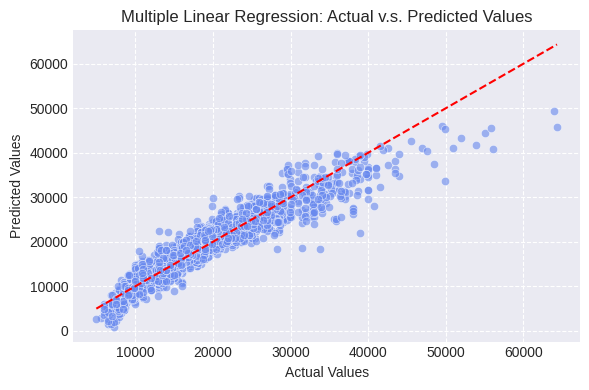

In [ ]:
pipeline_mlr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

param_grid_mlr = {}

best_model_mlr, best_params_mlr, mse_mlr, rmse_mlr, mae_mlr, r2_mlr = evaluate_model(
    'Multiple Linear Regression', pipeline_mlr, param_grid_mlr, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Multiple Linear Regression', 'mse': mse_mlr, 'rmse': rmse_mlr, 'mae': mae_mlr, 'r2': r2_mlr})
trained_models_pipeline.append({'name': 'Multiple Linear Regression', 'model': best_model_mlr})

In [ ]:
if not best_model_for_deployment or mse_mlr < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_mlr, best_params_mlr, mse_mlr, rmse_mlr, mae_mlr, r2_mlr)

#### 2. Polynomial Regression

--- Running GridSearchCV for Polynomial Regression ---
Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV 1/5] END features_poly__degree=1, features_poly__include_bias=False;, score=-6463342.351 total time=   0.2s
[CV 2/5] END features_poly__degree=1, features_poly__include_bias=False;, score=-6147254.258 total time=   0.2s
[CV 3/5] END features_poly__degree=1, features_poly__include_bias=False;, score=-6235816.232 total time=   0.2s
[CV 4/5] END features_poly__degree=1, features_poly__include_bias=False;, score=-6130154.667 total time=   0.2s
[CV 5/5] END features_poly__degree=1, features_poly__include_bias=False;, score=-5932155.064 total time=   0.2s
Polynomial Regression Results:
Best Hyperparameters: {'features_poly__degree': 1, 'features_poly__include_bias': False}
Training MSE (Cross-validation):  6181744.5144
Test MSE:  5796248.8521
Test RMSE:  2407.5400
Test MAE:  1715.3673
Test R-squared:  0.8926


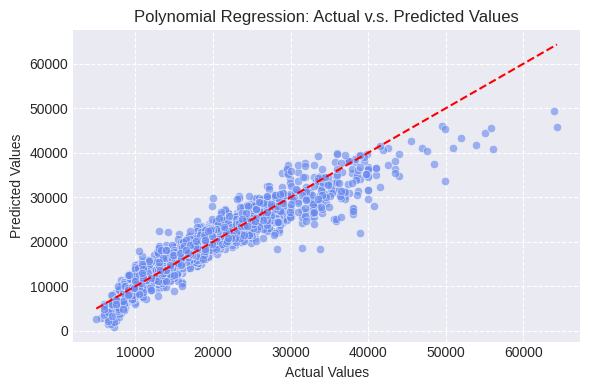

In [ ]:
pipeline_poly = Pipeline([
    ('features_poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

param_grid_poly = {
    'features_poly__degree': [1], #[1, 2, 3]
    'features_poly__include_bias': [False]
}

best_model_poly, best_params_poly, mse_poly, rmse_poly, mae_poly, r2_poly = evaluate_model(
    'Polynomial Regression', pipeline_poly, param_grid_poly, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Polynomial Regression', 'mse': mse_poly, 'rmse': rmse_poly, 'mae': mae_poly, 'r2': r2_poly})
trained_models_pipeline.append({'name': 'Polynomial Regression', 'model': best_model_poly})

In [ ]:
if not best_model_for_deployment or mse_poly < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_poly, best_params_poly, mse_poly, rmse_poly, mae_poly, r2_poly)

#### 3. Ridge Regression

--- Running GridSearchCV for Ridge Regression ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .....regressor__alpha=0.001;, score=-6463342.077 total time=   0.1s
[CV 2/5] END .....regressor__alpha=0.001;, score=-6147254.337 total time=   0.1s
[CV 3/5] END .....regressor__alpha=0.001;, score=-6235815.918 total time=   0.1s
[CV 4/5] END .....regressor__alpha=0.001;, score=-6130154.753 total time=   0.1s
[CV 5/5] END .....regressor__alpha=0.001;, score=-5932155.127 total time=   0.1s
[CV 1/5] END ......regressor__alpha=0.01;, score=-6463339.608 total time=   0.1s
[CV 2/5] END ......regressor__alpha=0.01;, score=-6147255.050 total time=   0.1s
[CV 3/5] END ......regressor__alpha=0.01;, score=-6235813.095 total time=   0.1s
[CV 4/5] END ......regressor__alpha=0.01;, score=-6130155.527 total time=   0.1s
[CV 5/5] END ......regressor__alpha=0.01;, score=-5932155.694 total time=   0.1s
[CV 1/5] END .......regressor__alpha=0.1;, score=-6463314.935 total time=   0.1s

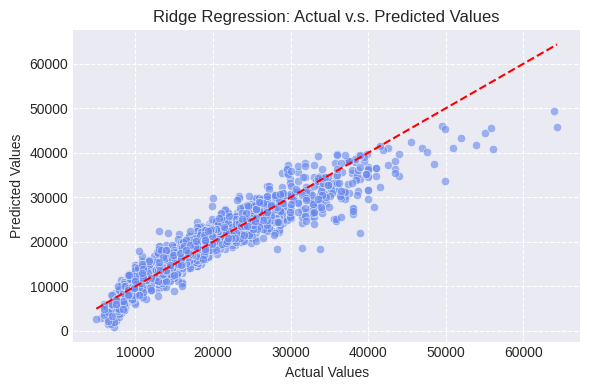

In [ ]:
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(random_state=42))
])

param_grid_ridge = {
    'regressor__alpha': np.logspace(-3, 3, 7)
}

best_model_ridge, best_params_ridge, mse_ridge, rmse_ridge, mae_ridge, r2_ridge = evaluate_model(
    'Ridge Regression', pipeline_ridge, param_grid_ridge, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Ridge Regression', 'mse': mse_ridge, 'rmse': rmse_ridge, 'mae': mae_ridge, 'r2': r2_ridge})
trained_models_pipeline.append({'name': 'Ridge Regression', 'model': best_model_ridge})

In [ ]:
if not best_model_for_deployment or mse_ridge < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_ridge, best_params_ridge, mse_ridge, rmse_ridge, mae_ridge, r2_ridge)

#### 4. Lasso Regression

--- Running GridSearchCV for Lasso Regression ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits
[CV 1/5] END .....regressor__alpha=0.001;, score=-6463341.528 total time=   7.5s
[CV 2/5] END .....regressor__alpha=0.001;, score=-6147252.510 total time=   2.2s
[CV 3/5] END .....regressor__alpha=0.001;, score=-6235807.872 total time=   2.0s
[CV 4/5] END .....regressor__alpha=0.001;, score=-6130155.612 total time=   2.0s
[CV 5/5] END .....regressor__alpha=0.001;, score=-5932153.530 total time=   2.4s
[CV 1/5] END ......regressor__alpha=0.01;, score=-6463334.224 total time=   3.0s
[CV 2/5] END ......regressor__alpha=0.01;, score=-6147236.900 total time=   5.7s
[CV 3/5] END ......regressor__alpha=0.01;, score=-6235732.748 total time=   1.6s
[CV 4/5] END ......regressor__alpha=0.01;, score=-6130164.241 total time=   1.7s
[CV 5/5] END ......regressor__alpha=0.01;, score=-5932139.886 total time=   1.8s
[CV 1/5] END .......regressor__alpha=0.1;, score=-6463268.269 total time=   1.2s

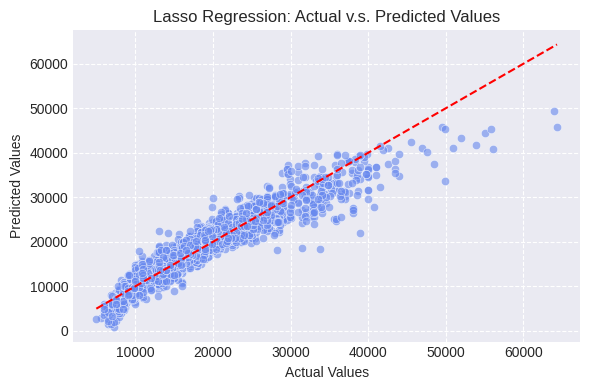

In [ ]:
pipeline_lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Lasso(random_state=42))
])

param_grid_lasso = {
    'regressor__alpha': np.logspace(-3, 3, 7)
}

best_model_lasso, best_params_lasso, mse_lasso, rmse_lasso, mae_lasso, r2_lasso = evaluate_model(
    'Lasso Regression', pipeline_lasso, param_grid_lasso, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Lasso Regression', 'mse': mse_lasso, 'rmse': rmse_lasso, 'mae': mae_lasso, 'r2': r2_lasso})
trained_models_pipeline.append({'name': 'Lasso Regression', 'model': best_model_lasso})

In [ ]:
if not best_model_for_deployment or mse_lasso < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_lasso, best_params_lasso, mse_lasso, rmse_lasso, mae_lasso, r2_lasso)

#### 5. ElasticNet Regression

--- Running GridSearchCV for ElasticNet Regression ---
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END regressor__alpha=0.1, regressor__l1_ratio=0.1;, score=-6620072.754 total time=   0.6s
[CV 2/5] END regressor__alpha=0.1, regressor__l1_ratio=0.1;, score=-6546670.252 total time=   0.7s
[CV 3/5] END regressor__alpha=0.1, regressor__l1_ratio=0.1;, score=-6476638.725 total time=   0.7s
[CV 4/5] END regressor__alpha=0.1, regressor__l1_ratio=0.1;, score=-6628668.789 total time=   0.7s
[CV 5/5] END regressor__alpha=0.1, regressor__l1_ratio=0.1;, score=-6270489.219 total time=   3.1s
[CV 1/5] END regressor__alpha=0.1, regressor__l1_ratio=0.5;, score=-6502624.955 total time=   2.9s
[CV 2/5] END regressor__alpha=0.1, regressor__l1_ratio=0.5;, score=-6341401.124 total time=   1.0s
[CV 3/5] END regressor__alpha=0.1, regressor__l1_ratio=0.5;, score=-6322167.191 total time=   0.6s
[CV 4/5] END regressor__alpha=0.1, regressor__l1_ratio=0.5;, score=-6386017.185 total time=

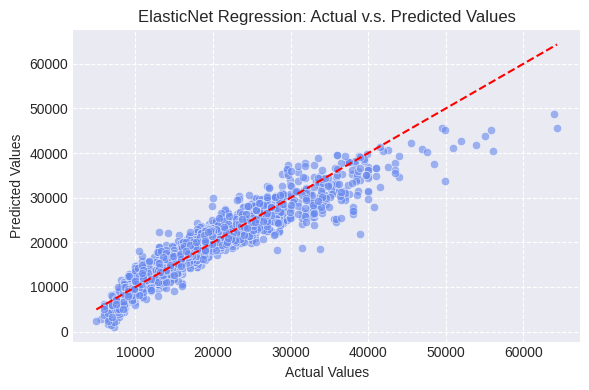

In [ ]:
pipeline_elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', ElasticNet(random_state=42, max_iter=10000))
])

param_grid_elasticnet = {
    'regressor__alpha': np.logspace(-1, 3, 5),
    'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

best_model_elasticnet, best_params_elasticnet, mse_elasticnet, rmse_elasticnet, mae_elasticnet, r2_elasticnet = evaluate_model(
    'ElasticNet Regression', pipeline_elasticnet, param_grid_elasticnet, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Elasticnet Regression', 'mse': mse_elasticnet, 'rmse': rmse_elasticnet, 'mae': mae_elasticnet, 'r2': r2_elasticnet})
trained_models_pipeline.append({'name': 'Elasticnet Regression', 'model': best_model_elasticnet})

In [ ]:
if not best_model_for_deployment or mse_elasticnet < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_elasticnet, best_params_elasticnet, mse_elasticnet, rmse_elasticnet, mae_elasticnet, r2_elasticnet)

#### 6. Decision Tree Regression

--- Running GridSearchCV for Decision Tree Regression ---
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2;, score=-5002251.281 total time=   0.5s
[CV 2/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2;, score=-4868411.418 total time=   0.4s
[CV 3/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2;, score=-4970547.340 total time=   0.4s
[CV 4/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2;, score=-4870634.774 total time=   0.4s
[CV 5/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=2;, score=-4805045.722 total time=   0.5s
[CV 1/5] END regressor__max_depth=None, regressor__min_samples_leaf=1, regressor__min_samples_split=5;, score=-5566554.066 total time=   0.4s
[CV 2/5] END regressor__max_

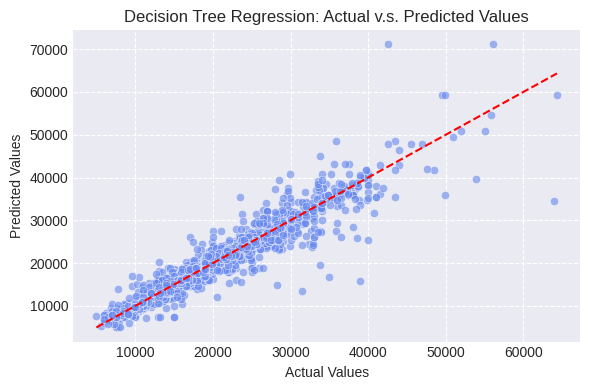

In [ ]:
pipeline_dt = Pipeline([
    ('regressor', DecisionTreeRegressor(random_state=42))
])

param_grid_dt = {
    'regressor__max_depth': [None, 5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

best_model_dt, best_params_dt, mse_dt, rmse_dt, mae_dt, r2_dt = evaluate_model(
    'Decision Tree Regression', pipeline_dt, param_grid_dt, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Decision Tree Regression', 'mse': mse_dt, 'rmse': rmse_dt, 'mae': mae_dt, 'r2': r2_dt})
trained_models_pipeline.append({'name': 'Decision Tree Regression', 'model': best_model_dt})

In [ ]:
if not best_model_for_deployment or mse_dt < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_dt, best_params_dt, mse_dt, rmse_dt, mae_dt, r2_dt)

#### 7. Random Forest Regression

--- Running GridSearchCV for Random Forest Regression ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50;, score=-3407933.748 total time=   8.3s
[CV 2/5] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50;, score=-2907870.807 total time=   5.4s
[CV 3/5] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50;, score=-3331260.402 total time=   7.6s
[CV 4/5] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50;, score=-3121027.782 total time=   7.1s
[CV 5/5] END regressor__max_depth=10, regressor__min_samples_leaf=1, regressor__min_samples_split=2, regressor__n_estimators=50;, score=-3414168.736 total time=   4.8s
[CV 1/5] END regressor__max_depth=10, re

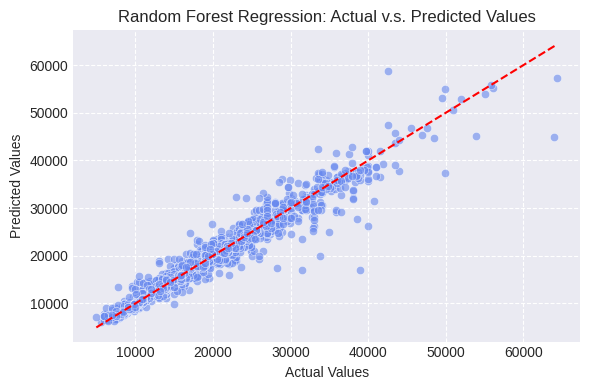

In [ ]:
pipeline_rf = Pipeline([
    ('regressor', RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

best_model_rf, best_params_rf, mse_rf, rmse_rf, mae_rf, r2_rf = evaluate_model(
    'Random Forest Regression', pipeline_rf, param_grid_rf, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Random Forest Regression', 'mse': mse_rf, 'rmse': rmse_rf, 'mae': mae_rf, 'r2': r2_rf})
trained_models_pipeline.append({'name': 'Random Forest Regression', 'model': best_model_rf})

In [ ]:
if not best_model_for_deployment or mse_rf < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_rf, best_params_rf, mse_rf, rmse_rf, mae_rf, r2_rf)

#### 8. AdaBoost Regression

--- Running GridSearchCV for Adaboost Regression ---
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV 1/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=50;, score=-16173702.586 total time=   4.2s
[CV 2/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=50;, score=-17415891.111 total time=   4.5s
[CV 3/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=50;, score=-15278774.017 total time=   5.1s
[CV 4/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=50;, score=-16474177.677 total time=   4.0s
[CV 5/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=50;, score=-17296560.138 total time=   4.1s
[CV 1/5] END regressor__learning_rate=0.01, regressor__loss=linear, regressor__n_estimators=100;, score=-14870930.949 total time=  10.1s
[CV 2/5] END regressor__learning_rate=0.01, regressor__loss=linear, 

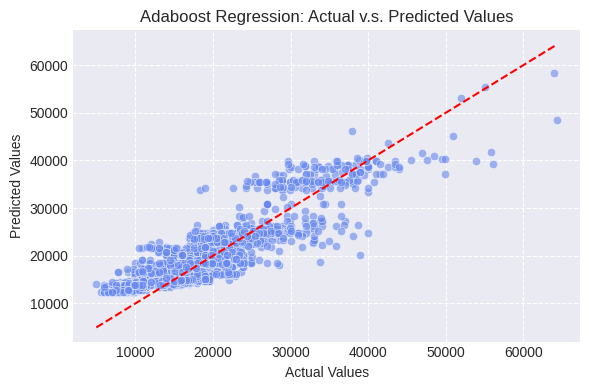

In [ ]:
pipeline_ada = Pipeline([
    ('regressor', AdaBoostRegressor(random_state=42))
])

param_grid_ada = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__learning_rate': [0.01, 0.1, 0.5],
    'regressor__loss': ['linear', 'square', 'exponential']
}

best_model_ada, best_params_ada, mse_ada, rmse_ada, mae_ada, r2_ada = evaluate_model(
    'Adaboost Regression', pipeline_ada, param_grid_ada, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'AdaBoost Regression', 'mse': mse_ada, 'rmse': rmse_ada, 'mae': mae_ada, 'r2': r2_ada})
trained_models_pipeline.append({'name': 'AdaBoost Regression', 'model': best_model_ada})

In [ ]:
if not best_model_for_deployment or mse_ada < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_ada, best_params_ada, mse_ada, rmse_ada, mae_ada, r2_ada)

#### 9. Gradient Boosting Regression

In [ ]:
pipeline_gbr = Pipeline([
    ('regressor', GradientBoostingRegressor(random_state=42))
])

param_grid_gbr = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.7, 0.9, 1.0]
}

best_model_gbr, best_params_gbr, mse_gbr, rmse_gbr, mae_gbr, r2_gbr = evaluate_model(
    'Gradient Boosting Regression', pipeline_gbr, param_grid_gbr, X_train, y_train, X_test, y_test
)

--- Running GridSearchCV for Gradient Boosting Regression ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-5263641.251 total time=   3.8s
[CV 2/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-4725581.762 total time=   4.4s
[CV 3/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-4789804.929 total time=   5.0s
[CV 4/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-5236944.732 total time=   3.8s
[CV 5/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-4991877.160 total time=   3.8s
[CV 1/5] END regressor__learning_rate=0.05, regressor__max_depth=3

In [ ]:
model_results.append({'name': 'Gradient Boosting Regression', 'mse': mse_gbr, 'rmse': rmse_gbr, 'mae': mae_gbr, 'r2': r2_gbr})
trained_models_pipeline.append({'name': 'Gradient Boosting Regression', 'model': best_model_gbr})

In [ ]:
if not best_model_for_deployment or mse_gbr < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_gbr, best_params_gbr, mse_gbr, rmse_gbr, mae_gbr, r2_gbr)

#### 10. XGBoost Regression

In [ ]:
pipeline_xgb = Pipeline([
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=42, n_jobs=-1))
])

param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.7, 0.9, 1.0]
}

best_model_xgb, best_params_xgb, mse_xgb, rmse_xgb, mae_xgb, r2_xgb = evaluate_model(
    'XGBoost Regression', pipeline_xgb, param_grid_xgb, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'XGBoost Regression', 'mse': mse_xgb, 'rmse': rmse_xgb, 'mae': mae_xgb, 'r2': r2_xgb})
trained_models_pipeline.append({'name': 'XGBoost Regression', 'model': best_model_xgb})

In [ ]:
if not best_model_for_deployment or mse_xgb < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_xgb, best_params_xgb, mse_xgb, rmse_xgb, mae_xgb, r2_xgb)

#### 11. LightGBM Regression

In [ ]:
pipeline_lgb = Pipeline([
    ('regressor', lgb.LGBMRegressor(objective='regression', metric='rmse', random_state=42, n_jobs=-1, verbose=-1))
])

param_grid_lgb = {
    'regressor__n_estimators': [20],
    'regressor__learning_rate': [0.1],
    'regressor__num_leaves': [10],
    'regressor__min_child_samples': [10]
}

best_model_lgb, best_params_lgb, mse_lgb, rmse_lgb, mae_lgb, r2_lgb = evaluate_model(
    'LightGBM Regression', pipeline_lgb, param_grid_lgb, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'LightGBM Regression', 'mse': mse_lgb, 'rmse': rmse_lgb, 'mae': mae_lgb, 'r2': r2_lgb})
trained_models_pipeline.append({'name': 'LightGBM Regression', 'model': best_model_lgb})

In [ ]:
if not best_model_for_deployment or mse_lgb < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_lgb, best_params_lgb, mse_lgb, rmse_lgb, mae_lgb, r2_lgb)

#### 12. CatBoost Regression

In [ ]:
pipeline_cb = Pipeline([
    ('regressor', CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False))
])

param_grid_cb = {
    'regressor__iterations': [100],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__depth': [6, 8],
    'regressor__l2_leaf_reg': [1, 3]
}

best_model_cb, best_params_cb, mse_cb, rmse_cb, mae_cb, r2_cb = evaluate_model(
    'CatBoost Regression', pipeline_cb, param_grid_cb, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'CatBoost Regression', 'mse': mse_cb, 'rmse': rmse_cb, 'mae': mae_cb, 'r2': r2_cb})
trained_models_pipeline.append({'name': 'CatBoost Regression', 'model': best_model_cb})

In [ ]:
if not best_model_for_deployment or mse_cb < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_cb, best_params_cb, mse_cb, rmse_cb, mae_cb, r2_cb)

#### 13. SVM Regression

--- Running GridSearchCV for Support Vector Regression ---
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END regressor__C=0.1, regressor__epsilon=0.01, regressor__kernel=linear;, score=-22100155.910 total time=  16.4s
[CV 2/5] END regressor__C=0.1, regressor__epsilon=0.01, regressor__kernel=linear;, score=-24241293.995 total time=  16.6s
[CV 3/5] END regressor__C=0.1, regressor__epsilon=0.01, regressor__kernel=linear;, score=-21320458.123 total time=  16.6s
[CV 4/5] END regressor__C=0.1, regressor__epsilon=0.01, regressor__kernel=linear;, score=-23666772.270 total time=  16.9s
[CV 5/5] END regressor__C=0.1, regressor__epsilon=0.01, regressor__kernel=linear;, score=-23360241.800 total time=  18.2s
[CV 1/5] END regressor__C=0.1, regressor__epsilon=0.1, regressor__kernel=linear;, score=-22100195.031 total time=  16.2s
[CV 2/5] END regressor__C=0.1, regressor__epsilon=0.1, regressor__kernel=linear;, score=-24241244.391 total time=  15.1s
[CV 3/5] END regressor__C=0.1

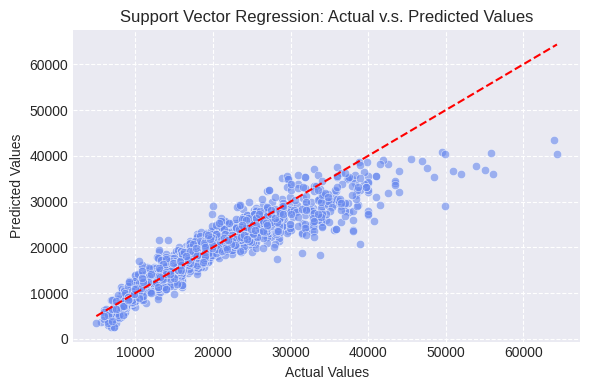

In [ ]:
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR())
])

param_grid_svr = {
    'regressor__kernel': ['linear'],
    'regressor__C': [0.1, 1, 10],
    'regressor__epsilon': [0.01, 0.1, 0.2]
}

best_model_svr, best_params_svr, mse_svr, rmse_svr, mae_svr, r2_svr = evaluate_model(
    'Support Vector Regression', pipeline_svr, param_grid_svr, X_train, y_train, X_test, y_test
)

In [ ]:
model_results.append({'name': 'Support Vector Regression', 'mse': mse_svr, 'rmse': rmse_svr, 'mae': mae_svr, 'r2': r2_svr})
trained_models_pipeline.append({'name': 'Support Vector Regression', 'model': best_model_svr})

In [ ]:
if not best_model_for_deployment or mse_svr < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_svr, best_params_svr, mse_svr, rmse_svr, mae_svr, r2_svr)

#### 14. KNN Regression

--- Running GridSearchCV for K-Nearest Neighbors Regression ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV 1/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=uniform;, score=-7349406.180 total time=   5.7s
[CV 2/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=uniform;, score=-7434245.963 total time=   6.7s
[CV 3/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=uniform;, score=-6259730.864 total time=   5.5s
[CV 4/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=uniform;, score=-7271417.144 total time=   6.7s
[CV 5/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=uniform;, score=-6234664.239 total time=   5.7s
[CV 1/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=distance;, score=-6881632.979 total time=   5.8s
[CV 2/5] END regressor__n_neighbors=3, regressor__p=1, regressor__weights=distance;, score=-6915331.146 total time=   6.5s
[CV 3/5] END regres

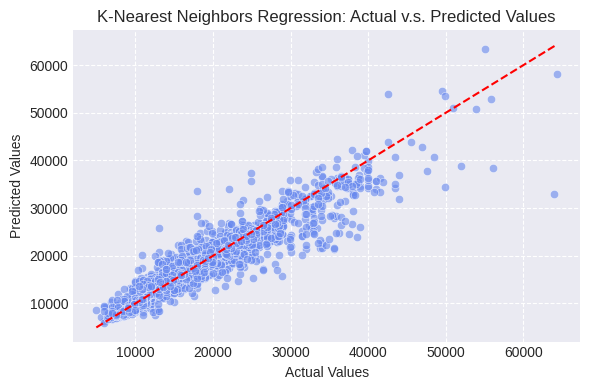

In [64]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', KNeighborsRegressor())
])

param_grid_knn = {
    'regressor__n_neighbors': [3, 5, 7, 9],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__p': [1, 2]
}

best_model_knn, best_params_knn, mse_knn, rmse_knn, mae_knn, r2_knn = evaluate_model(
    'K-Nearest Neighbors Regression', pipeline_knn, param_grid_knn, X_train, y_train, X_test, y_test
)

In [65]:
model_results.append({'name': 'K-Nearest Neighbors Regression', 'mse': mse_knn, 'rmse': rmse_knn, 'mae': mae_knn, 'r2': r2_knn})
trained_models_pipeline.append({'name': 'K-Nearest Neighbors Regression', 'model': best_model_knn})

In [66]:
if not best_model_for_deployment or mse_knn < best_model_for_deployment[2]:
    best_model_for_deployment = (best_model_knn, best_params_knn, mse_knn, rmse_knn, mae_knn, r2_knn)

### Model comparison

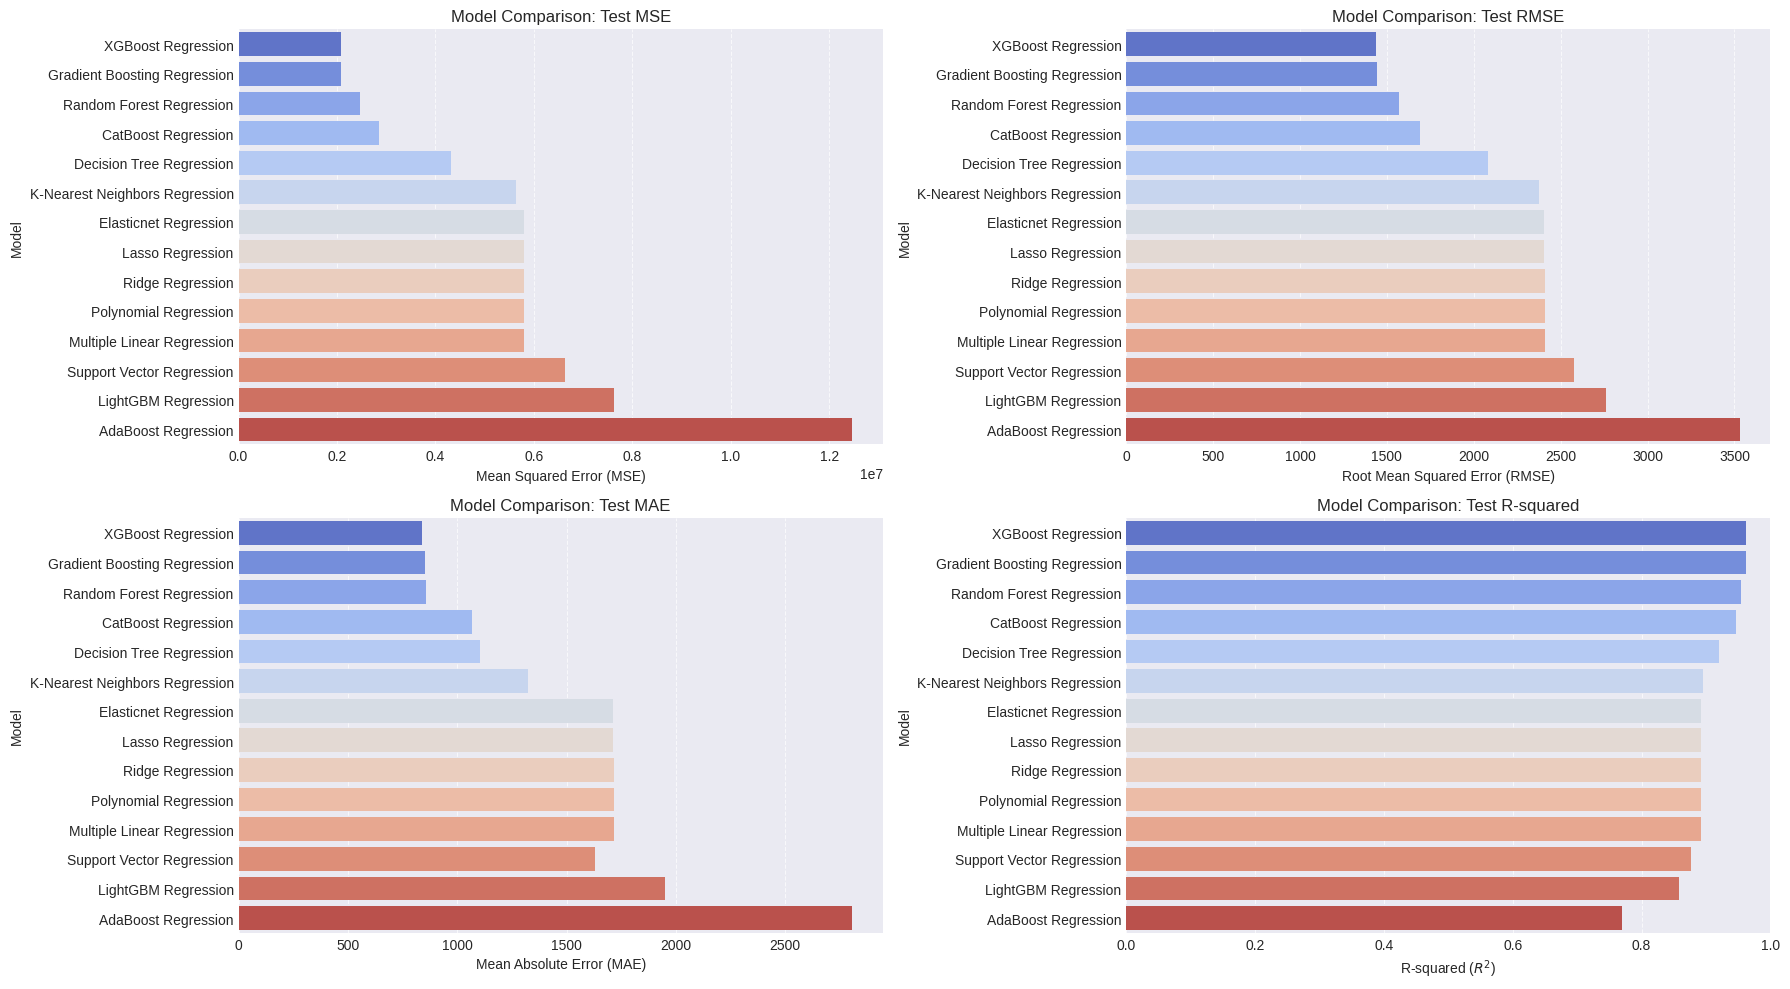

In [76]:
compare_models(model_results)

### Model building with important features

In [79]:
def get_feature_importance_from_models_pipeline(trained_models_pipeline, feature_names_original):

    df_importances = {}

    for model_info in trained_models_pipeline:
        model_name = model_info['name']
        model_pipeline = model_info['model']

        regressor = model_pipeline.named_steps['regressor']

        importances = None
        feature_names_current = feature_names_original
        importance_type = 'Value'

        if 'features_poly' in model_pipeline.named_steps:
            transformer_poly = model_pipeline.named_steps['features_poly']
            feature_names_current = transformer_poly.get_feature_names_out(feature_names_original)

        if hasattr(regressor, 'feature_importances_'):
            importances = regressor.feature_importances_
            importance_type = 'Feature Importance'
        elif hasattr(regressor, 'coef_'):
            if len(regressor.coef_) == len(feature_names_current):
                importances = np.abs(regressor.coef_)
                importance_type = 'Absolute Coefficient'
            else:
                print(f'{model_name} has coef_ but its length {len(regressor.coef_)} does not match transformed feature count {len(feature_names_current)}.')
                continue
        else:
            print(f'{model_name}: Regressor does not have feature_importances_ or coef_ attribute.')
            continue

        if importances is not None:
            df_temp = pd.DataFrame({'Feature': feature_names_current, 'Importance': importances})
            df_temp = df_temp.sort_values(by='Importance', ascending=False)
            df_importances[model_name] = df_temp

            print(f'\n{model_name} {importance_type}:')
            print(f'\n{df_temp.head(10)}')

            plt.figure(figsize=(6, max(4, len(df_temp.head(10))*0.2)))
            sns.barplot(x='Importance', y='Feature', hue='Feature', data=df_temp.head(10), palette='coolwarm', legend=False)
            plt.title(f'{model_name} {importance_type}', fontsize=12)
            plt.xlabel(importance_type, fontsize=10)
            plt.ylabel('Feature', fontsize=10)
            plt.tight_layout()
            plt.show()


    return df_importances



Multiple Linear Regression Absolute Coefficient:

                      Feature   Importance
2                          hp  2634.206636
20    make_model_Renault Clio  1767.845662
18      make_model_Opel Corsa  1765.604563
13                       year  1675.823834
0                          km  1479.026020
17      make_model_Opel Astra  1396.831014
36              new_used_Used  1327.987738
22  make_model_Renault Espace   974.918418
33    new_used_Employee's car   751.465922
35    new_used_Pre-registered   656.999558


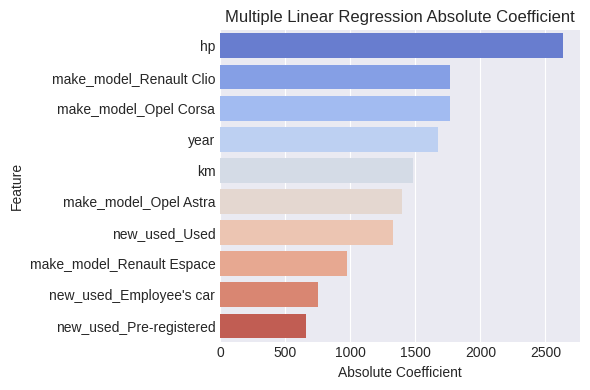


Polynomial Regression Absolute Coefficient:

                      Feature   Importance
2                          hp  2634.206636
20    make_model_Renault Clio  1767.845662
18      make_model_Opel Corsa  1765.604563
13                       year  1675.823834
0                          km  1479.026020
17      make_model_Opel Astra  1396.831014
36              new_used_Used  1327.987738
22  make_model_Renault Espace   974.918418
33    new_used_Employee's car   751.465922
35    new_used_Pre-registered   656.999558


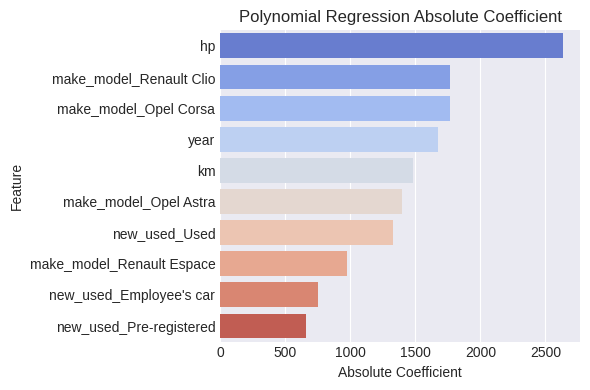


Ridge Regression Absolute Coefficient:

                      Feature   Importance
2                          hp  2619.108868
18      make_model_Opel Corsa  1756.671352
20    make_model_Renault Clio  1755.305439
13                       year  1674.807952
0                          km  1478.358926
17      make_model_Opel Astra  1384.386410
36              new_used_Used  1319.772375
22  make_model_Renault Espace   979.314266
33    new_used_Employee's car   745.940546
35    new_used_Pre-registered   650.938305


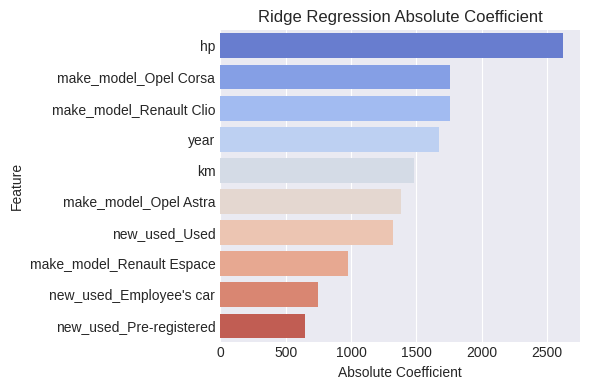


Lasso Regression Absolute Coefficient:

                      Feature   Importance
2                          hp  2621.728728
18      make_model_Opel Corsa  1755.898950
20    make_model_Renault Clio  1755.404229
13                       year  1678.701482
0                          km  1477.393772
17      make_model_Opel Astra  1386.390511
36              new_used_Used  1315.944092
22  make_model_Renault Espace   976.341537
33    new_used_Employee's car   743.324777
35    new_used_Pre-registered   647.583059


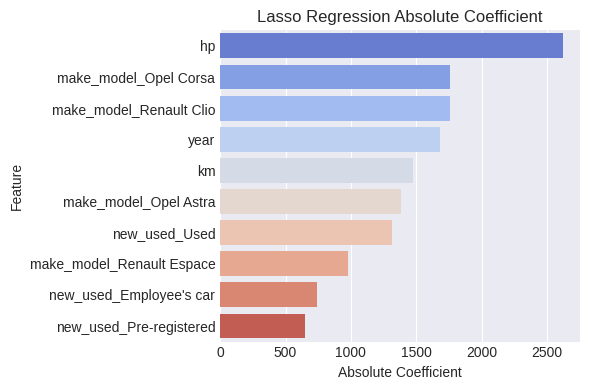


Elasticnet Regression Absolute Coefficient:

                      Feature   Importance
2                          hp  2469.642731
18      make_model_Opel Corsa  1665.377782
13                       year  1660.873686
20    make_model_Renault Clio  1628.665464
0                          km  1470.064260
17      make_model_Opel Astra  1261.908576
36              new_used_Used  1232.934908
22  make_model_Renault Espace  1012.116924
33    new_used_Employee's car   687.268272
35    new_used_Pre-registered   587.095900


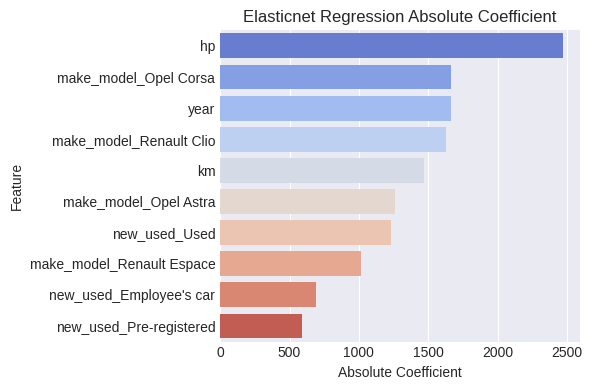


Decision Tree Regression Feature Importance:

                      Feature  Importance
2                          hp    0.513976
13                       year    0.202031
0                          km    0.065435
22  make_model_Renault Espace    0.054241
11                      gears    0.026254
9                      weight    0.022431
48        gearing_type_Manual    0.012460
16         make_model_Audi A3    0.012338
14           consumption_comb    0.011688
17      make_model_Opel Astra    0.007359


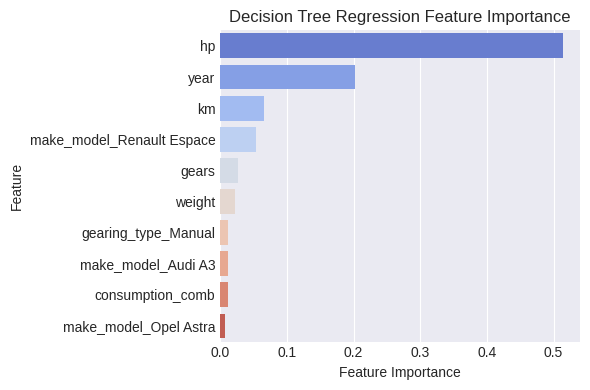


Random Forest Regression Feature Importance:

                      Feature  Importance
2                          hp    0.493351
13                       year    0.194533
0                          km    0.069890
22  make_model_Renault Espace    0.055851
11                      gears    0.025267
9                      weight    0.018086
16         make_model_Audi A3    0.013085
48        gearing_type_Manual    0.012107
14           consumption_comb    0.010285
17      make_model_Opel Astra    0.008961


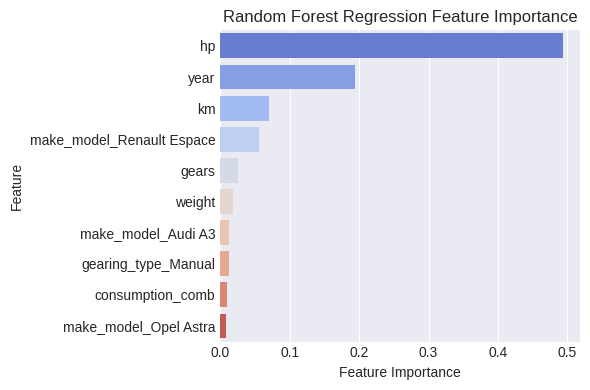


AdaBoost Regression Feature Importance:

                      Feature  Importance
2                          hp    0.430126
0                          km    0.105716
88              panorama_roof    0.074981
13                       year    0.064453
14           consumption_comb    0.054111
9                      weight    0.053057
81              leather_seats    0.042374
11                      gears    0.033497
22  make_model_Renault Espace    0.021563
77           heads-up_display    0.013776


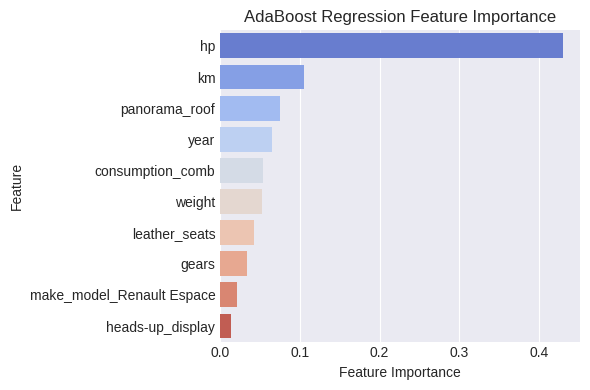


Gradient Boosting Regression Feature Importance:

                      Feature  Importance
2                          hp    0.486006
13                       year    0.166659
0                          km    0.092694
22  make_model_Renault Espace    0.044410
11                      gears    0.024727
9                      weight    0.022112
16         make_model_Audi A3    0.018570
48        gearing_type_Manual    0.011008
10               co2_emission    0.009109
14           consumption_comb    0.008603


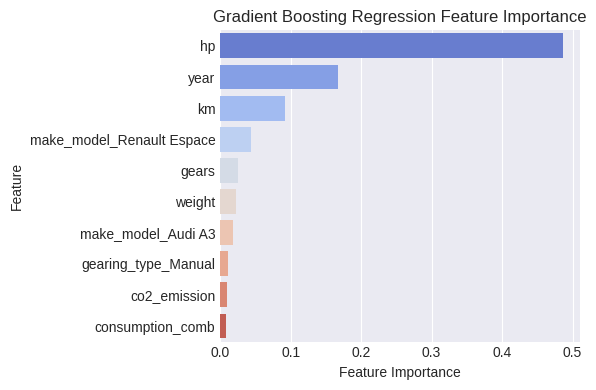


XGBoost Regression Feature Importance:

                         Feature  Importance
22     make_model_Renault Espace    0.231547
2                             hp    0.157532
13                          year    0.109917
16            make_model_Audi A3    0.056606
11                         gears    0.035144
17         make_model_Opel Astra    0.031501
8                      cylinders    0.030550
18         make_model_Opel Corsa    0.023497
129             'LED Headlights'    0.019170
49   gearing_type_Semi-automatic    0.018691


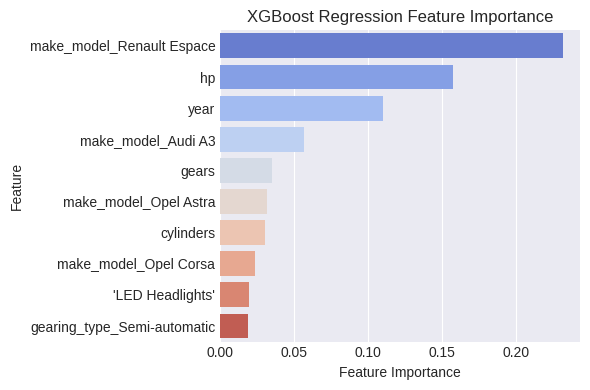


LightGBM Regression Feature Importance:

                      Feature  Importance
2                          hp          46
13                       year          25
0                          km          20
11                      gears          12
22  make_model_Renault Espace          12
16         make_model_Audi A3          11
9                      weight           7
18      make_model_Opel Corsa           4
48        gearing_type_Manual           4
19   make_model_Opel Insignia           4


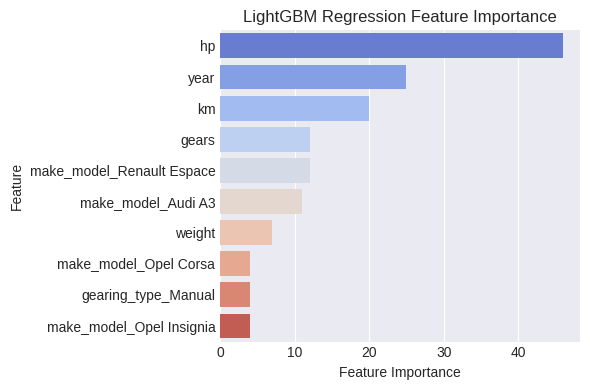


CatBoost Regression Feature Importance:

                      Feature  Importance
2                          hp   23.460338
13                       year   17.584808
0                          km   10.640823
22  make_model_Renault Espace    7.111508
11                      gears    4.801090
16         make_model_Audi A3    4.079892
19   make_model_Opel Insignia    2.747203
48        gearing_type_Manual    2.449897
9                      weight    1.968073
10               co2_emission    1.762930


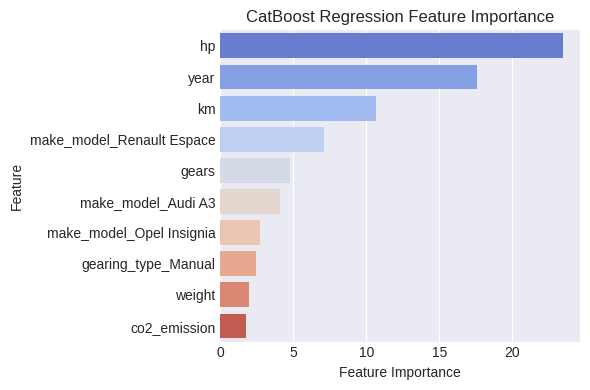

Support Vector Regression has coef_ but its length 1 does not match transformed feature count 139.
K-Nearest Neighbors Regression: Regressor does not have feature_importances_ or coef_ attribute.


In [80]:
df_feature_importances = get_feature_importance_from_models_pipeline(trained_models_pipeline, X_train.columns)

In [ ]:
df_feature_importances

#### Training best model using selected features

In [71]:
def select_top_features_for_model_building_pipeline(top_n, model_results, df_feature_importances, X_train):

    best_model_name = None
    min_mse = float('inf')

    for result in model_results:
        if result['mse'] < min_mse:
            min_mse = result['mse']
            best_model_name = result['name']

    if not best_model_name or best_model_name not in df_feature_importances:
        print('Could not identify best model or its feature importances for feature selection.')
        return

    df_best_model_feature_importances = df_feature_importances[best_model_name]
    best_model_feature_selected = df_best_model_feature_importances['Feature'].head(top_n).tolist()
    final_feature_selected = [f for f in best_model_feature_selected if f in X_train.columns]

    if not final_feature_selected:
        print('No original features could be selected based on importance. Build model with all original features')
        final_feature_selected = X_train.columns.tolist()

    return best_model_name, final_feature_selected


In [72]:
final_model_name, final_feature_used = select_top_features_for_model_building_pipeline(10, model_results, df_feature_importances, X_train)

--- Running GridSearchCV for XGBoost Regression ---
Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV 1/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-5240285.000 total time=   0.6s
[CV 2/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-4764131.500 total time=   0.6s
[CV 3/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-4765777.500 total time=   0.6s
[CV 4/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-5173658.500 total time=   1.0s
[CV 5/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=100, regressor__subsample=0.7;, score=-5022735.500 total time=   1.7s
[CV 1/5] END regressor__learning_rate=0.05, regressor__max_depth=3, regresso

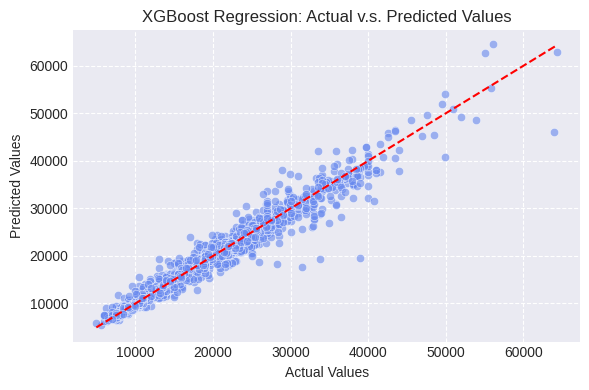

In [73]:
X_train_selected = X_train[final_feature_used]
X_test_selected = X_test[final_feature_used]

pipeline_xgb = Pipeline([
    ('regressor', xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', random_state=42, n_jobs=-1))
])

param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.05, 0.1, 0.2],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.7, 0.9, 1.0]
}

best_model_xgb, best_params_xgb, mse_xgb, rmse_xgb, mae_xgb, r2_xgb = evaluate_model(
    'XGBoost Regression', pipeline_xgb, param_grid_xgb, X_train, y_train, X_test, y_test
)

### Model deployment and new data prediction

In [78]:
if best_model_for_deployment:
    print('--- Deploying Best Regression Model (Pipeline-based) ---')

    best_model, best_params, best_mse, best_rmse, best_mae, best_r2 = best_model_for_deployment
    print(f'Best regression model: {best_model.named_steps['regressor']}')
    print(f'Performance metrics: MSE={best_mse:.4f}, RMSE={best_rmse:.4f}, MAE={best_mae:.4f}, R2={best_r2:.4f}')

    model_filename = drive_model_dir+'/best_regression_model_pipeline.joblib'
    joblib.dump(best_model, model_filename)
    print(f'Best regression model saved to {model_filename}')

    regression_model_loaded = joblib.load(model_filename)
    print(f'Best regression model loaded from {model_filename}')

    new_data_point_df = pd.DataFrame(np.array([[28000.0,1.0,140.0,1,1.0,5.0,5.0,1798.0,4.0,1380.0,105.0,7.0,0,2021.0,4.6,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,1,1,0,0,1,1,0,0,1,0,1,1,0,1,1,1,1,0,1,1,1,0,1,0,1,0,1,1,0,1,1,1,1,0,1,1,1,1,0,1,1,0,0,1,1,1,1,0,0,1,0,0,1,0,0,1,0,1,1,0,0,1,0,0,0,0,0,1,1,0,1,1,0,0,1,0,1,1,0,0,0,1,1,0,1,1,1,0]]), columns=X_train.columns)

    predicted_value = regression_model_loaded.predict(new_data_point_df)
    print(f'Predicted value: {predicted_value[0]:.4f}')
else:
    print('No regression model was successfully trained for deployment demonstration.')


--- Deploying Best Regression Model (Pipeline-based) ---
Best regression model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)
Performance metrics: MSE=2072109.5000, RMSE=1439.4824, MAE=837.6612, R2=0.9616
Best regression model saved to /content/drive/MyDrive/project/autoscout/model/best_regression_mod